In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import (
    load_digits, make_swiss_roll, make_moons, make_blobs
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from umap import UMAP
from time import time

np.random.seed(42)

# 2.1  Generate and visualise 

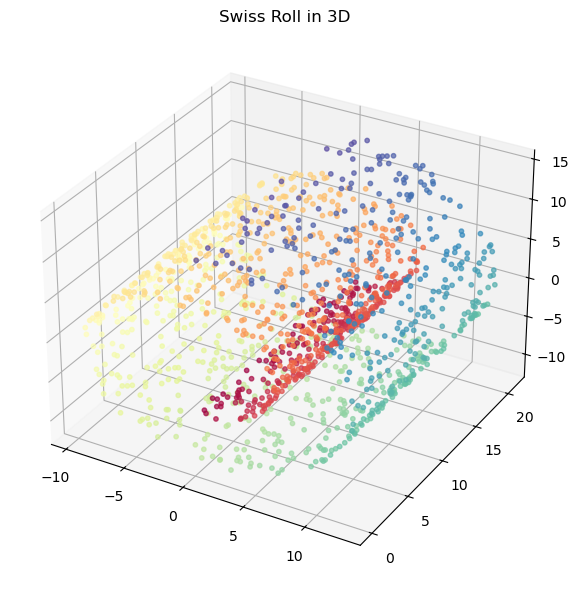

In [23]:
X_roll, t_roll = make_swiss_roll(n_samples=1500, noise=0.1, random_state=42)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2],
           c=t_roll, cmap='Spectral', s=10, alpha=0.7)
ax.set_title("Swiss Roll in 3D")
plt.tight_layout(); plt.show()



# PCA projection

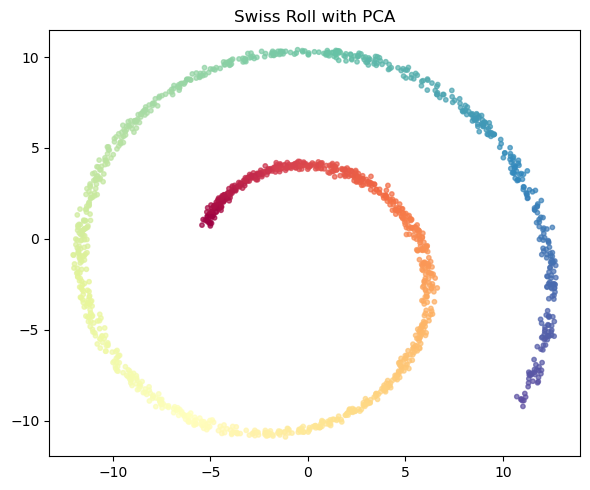

In [24]:
X_roll_pca = PCA(n_components=2).fit_transform(X_roll)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_roll_pca[:, 0], X_roll_pca[:, 1],
           c=t_roll, cmap='Spectral', s=10, alpha=0.7)
ax.set_title("Swiss Roll with PCA")
plt.tight_layout()
plt.show()


ANSWER: PCA does NOT unroll the manifold. It projects onto the two directions of maximum variance, which squashes the roll flat. The colours are interleaved: nearby points in the projection can have very different positions along the roll.

# 2.3  t-SNE embedding

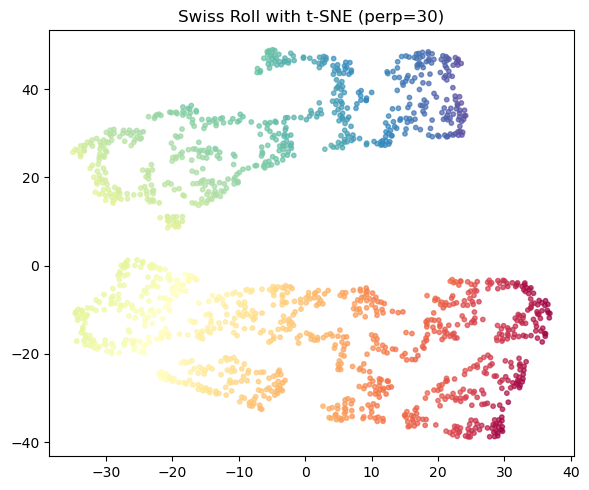

In [25]:
X_roll_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_roll)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_roll_tsne[:, 0], X_roll_tsne[:, 1],
           c=t_roll, cmap='Spectral', s=10, alpha=0.7)
ax.set_title("Swiss Roll with t-SNE (perp=30)")
plt.tight_layout()
plt.show()


ANSWER: t-SNE usually does a partial job. It tends to tear the roll into several fragments where the colour gradient is locally smooth but globally discontinuous. It preserves local neighbourhood well but struggles with the global ordering.


# 2.4  UMAP embedding

/opt/anaconda3/envs/graph/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


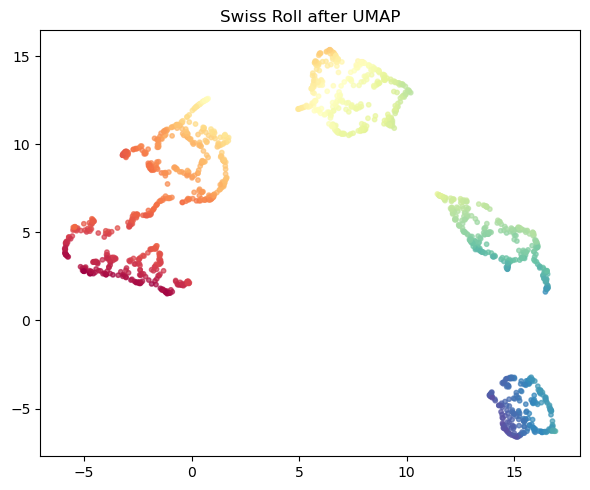

In [26]:
X_roll_umap = UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    random_state=42).fit_transform(X_roll)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_roll_umap[:, 0], X_roll_umap[:, 1],
           c=t_roll, cmap='Spectral', s=10, alpha=0.7)
ax.set_title("Swiss Roll after UMAP")
plt.tight_layout()
plt.show()


ANSWER: UMAP typically preserves the global structure a bit better than t-SNE (the colour gradient is often more continuous). However, neither method perfectly unrolls the Swiss roll (that would require methods specifically designed for manifold unfolding, like Isomap or locally linear embedding).

# Hyperparameter sensitivity

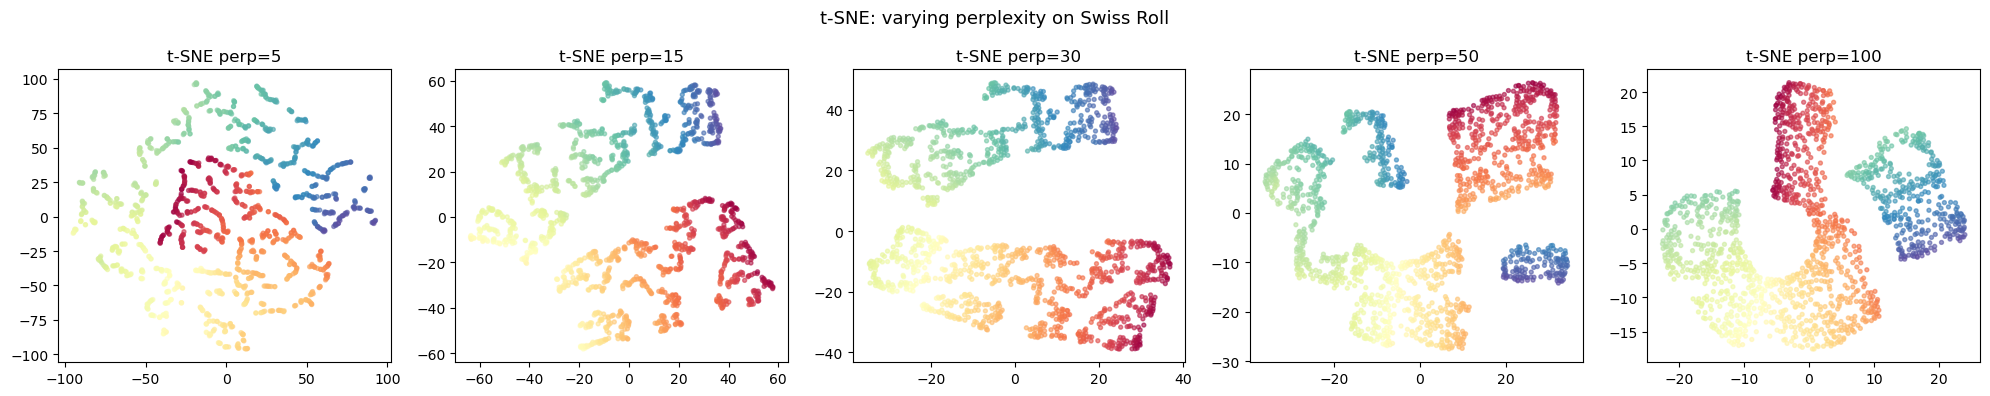

In [27]:
# t-SNE with different perplexities
perplexities = [5, 15, 30, 50, 100]
fig, axes = plt.subplots(1, len(perplexities), figsize=(20, 4))
for ax, perp in zip(axes, perplexities):
    X_emb = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(X_roll)
    ax.scatter(X_emb[:, 0], X_emb[:, 1], c=t_roll, cmap='Spectral', s=8, alpha=0.6)
    ax.set_title(f"t-SNE perp={perp}")
plt.suptitle("t-SNE: varying perplexity on Swiss Roll", fontsize=13)
plt.tight_layout()
plt.show()


/opt/anaconda3/envs/graph/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/graph/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/graph/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/graph/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


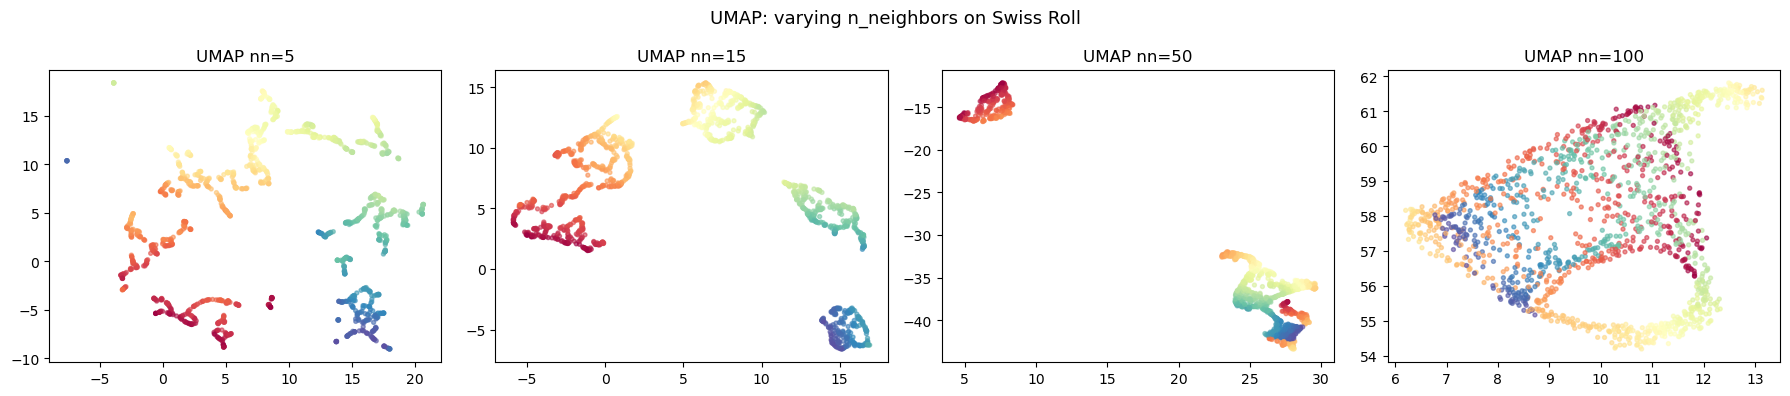

In [28]:
# UMAP with different n_neighbors
n_neighbors_list = [5, 15, 50, 100]
fig, axes = plt.subplots(1, len(n_neighbors_list), figsize=(18, 4))
for ax, nn in zip(axes, n_neighbors_list):
    X_emb = UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                  random_state=42).fit_transform(X_roll)
    ax.scatter(X_emb[:, 0], X_emb[:, 1], c=t_roll, cmap='Spectral', s=8, alpha=0.6)
    ax.set_title(f"UMAP nn={nn}")
plt.suptitle("UMAP: varying n_neighbors on Swiss Roll", fontsize=13)
plt.tight_layout()
plt.show()


ANSWERS:
- t-SNE with very low perplexity (5): many small disconnected fragments.
  The method sees only very local neighbourhoods and cannot stitch them
  together globally.
- t-SNE with high perplexity (100): smoother but may start to mix colours
  because the effective neighbourhood is so large it bridges across folds.
- UMAP with small n_neighbors (5): similar to low perplexity, fragmented.
- UMAP with large n_neighbors (100): very messy, local detail is lost and computation is slower.

Conclusion: both methods have a locality parameter that controls the local-vs-global trade-off. The range of stability is relitvely large (avoid both extremes)